# 05 - Evaluation and comparison

Section **3.5 Evaluation and comparison** of the report.

## Brief

The most important section. Reporting an accuracy number is not enough.

**Classification**: accuracy, precision, recall, F1-score, confusion matrix (mandatory for both models). ROC/AUC is optional but valued.

**Regression**: MAE, RMSE, R2, predicted-vs-actual plot.

**Critical analysis**:

- Which model performed best and why.
- Did the neural network beat the classical ML model? Was that expected given the dataset?
- Any signs of overfitting? How is it detected and mitigated?
- Which features were most relevant?
- What would you improve with more time or more data?

In [1]:
import json
import os
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import torch
import wandb
from dotenv import load_dotenv
from scipy import sparse
from torch import nn

from diplo_mod_1.constants import CONFIGS, MODELS, POINTS_BINS, PROCESSED, RANDOM_STATE, REPORTS
from diplo_mod_1.training.config import TuningHistory
from diplo_mod_1.training.nn_model import WineScoreNet, WineScorePredictorNet
from diplo_mod_1.training.shap_support import patch_shap_xgboost_base_score

load_dotenv(override=True)
patch_shap_xgboost_base_score()  # shap 0.49.1 vs XGBoost 3.x base_score format — see shap_support.py

# Experiment tracking is opt-in: set WANDB_ENABLED=true (in .env or the shell)
# to log this comparison to Weights & Biases. Off by default so `poe check` /
# nbmake executions don't create a W&B run on every lint/test pass.
WANDB_ENABLED = os.environ.get("WANDB_ENABLED", "false").lower() == "true"

## Step 1 — Load test data

Both models were trained on the same 2044-column representation (44 tabular + 2000 TF-IDF) but with different tabular scaling (XGBoost: unscaled; NN: scaled continuous columns) — load both, plus the shared `y_test` (confirmed byte-identical between `data/processed/xgboost/` and `data/processed/nn/`, same split from notebook 02).

In [2]:
xgb_dir = PROCESSED / "xgboost"
nn_dir = PROCESSED / "nn"

X_test_tab_unscaled = np.load(xgb_dir / "X_test.npy")
X_test_tab_scaled = np.load(nn_dir / "X_tab_test.npy")
X_test_txt = sparse.load_npz(nn_dir / "X_txt_test.npz")
y_test = np.load(nn_dir / "y_test.npy")

feature_meta = json.loads((xgb_dir / "feature_names.json").read_text(encoding="utf-8"))
tabular_feature_names = feature_meta["feature_names"]
tfidf_vectorizer = joblib.load(nn_dir / "tfidf_vectorizer.joblib")
text_feature_names = list(tfidf_vectorizer.get_feature_names_out())
feature_names = tabular_feature_names + text_feature_names

# XGBoost's best run trained on unscaled tabular + TF-IDF (notebook 03 Step 10);
# the NN trained on scaled tabular + TF-IDF, densified (notebook 04 Step 1).
X_test_xgb = sparse.hstack([sparse.csr_matrix(X_test_tab_unscaled), X_test_txt], format="csr")
X_test_nn = (
    sparse.hstack([sparse.csr_matrix(X_test_tab_scaled), X_test_txt], format="csr")
    .toarray()
    .astype(np.float32)
)

print(f"y_test: {y_test.shape}")
print(f"X_test_xgb (unscaled tabular + TF-IDF): {X_test_xgb.shape}")
print(f"X_test_nn  (scaled tabular + TF-IDF, dense): {X_test_nn.shape}")

if WANDB_ENABLED:
    wandb.init(
        project=os.environ.get("WANDB_PROJECT", "diplo-mod-1"),
        name=f"comparison-{datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')}",
        group="model-comparison",
        job_type="evaluation",
        config={"n_test_rows": int(y_test.shape[0])},
    )

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


y_test: (25995,)
X_test_xgb (unscaled tabular + TF-IDF): (25995, 2044)
X_test_nn  (scaled tabular + TF-IDF, dense): (25995, 2044)


wandb: Currently logged in as: leonardo-heis (leonardo-a-heis) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Step 2 — Load both best models

XGBoost's `.joblib` is a fully picklable, ready-to-predict object. The NN's `.pt` checkpoint only holds `state_dict` + architecture config, so `WineScoreNet` is reconstructed from it, then wrapped in a `WineScorePredictorNet` (assigning `model_` directly, skipping `.fit()`) to reuse its device-aware, batched `predict()` instead of writing new inference code.

In [3]:
xgb_model = joblib.load(MODELS / "xgboost_best.joblib")

checkpoint = torch.load(MODELS / "nn_best.pt", map_location="cpu")
# nn_best.pt predates NNModelRegistry persisting `activation` -- known from
# this session's run to be 'gelu'; new checkpoints self-describe correctly.
checkpoint_activation = checkpoint.get("activation", "gelu")
nn_net = WineScoreNet(
    input_dim=checkpoint["input_dim"],
    hidden_sizes=checkpoint["hidden_sizes"],
    dropout=checkpoint["dropout"],
    activation=checkpoint_activation,
)
nn_net.load_state_dict(checkpoint["state_dict"])
nn_net.eval()

nn_model = WineScorePredictorNet(
    input_dim=checkpoint["input_dim"],
    hidden_sizes=checkpoint["hidden_sizes"],
    dropout=checkpoint["dropout"],
    activation=checkpoint_activation,
    device="cpu",
)
nn_model.model_ = nn_net

print(f"XGBoost: n_features_in_={xgb_model.n_features_in_}")
print(
    f"NN: input_dim={checkpoint['input_dim']}, hidden_sizes={checkpoint['hidden_sizes']}, "
    f"activation={checkpoint_activation}"
)

XGBoost: n_features_in_=2044
NN: input_dim=2044, hidden_sizes=[512, 128, 32], activation=gelu


## Step 3 — Generate test-set predictions

In [4]:
xgb_pred = xgb_model.predict(X_test_xgb)
nn_pred = nn_model.predict(X_test_nn)

print(f"XGBoost predictions: {xgb_pred.shape}")
print(f"NN predictions:      {nn_pred.shape}")

c:\Users\leona\source\repos\diplo-mod-1\.venv\lib\site-packages\xgboost\core.py:751: UserWarning: [22:25:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


XGBoost predictions: (25995,)
NN predictions:      (25995,)


## Step 4 — Metrics comparison

Reuses each model's already-computed train/val/test metrics from its own `TuningHistory` (`reports/xgboost_metrics.json`, `reports/nn_metrics.json`) — same values each training notebook's own "compare all runs" step already verified, not recomputed here.

In [5]:
xgb_history = TuningHistory.model_validate_json(
    (REPORTS / "xgboost_metrics.json").read_text(encoding="utf-8")
)
nn_history = TuningHistory.model_validate_json(
    (REPORTS / "nn_metrics.json").read_text(encoding="utf-8")
)
xgb_best = xgb_history.best_run(split="test")
nn_best = nn_history.best_run(split="test")
assert xgb_best is not None and nn_best is not None

rows = []
for label, run in (("XGBoost", xgb_best), ("Neural Net", nn_best)):
    by_split = {m.split: m for m in run.metrics}
    rows.append(
        {
            "model": label,
            "run_id": run.run_id,
            "train_rmse": by_split["train"].rmse,
            "train_mae": by_split["train"].mae,
            "train_r2": by_split["train"].r2,
            "val_rmse": by_split["val"].rmse,
            "val_mae": by_split["val"].mae,
            "val_r2": by_split["val"].r2,
            "test_rmse": by_split["test"].rmse,
            "test_mae": by_split["test"].mae,
            "test_r2": by_split["test"].r2,
        }
    )
comparison_df = pd.DataFrame(rows)

if WANDB_ENABLED:
    wandb.log(
        {
            "comparison_table": wandb.Table(dataframe=comparison_df),
            "xgboost_run_id": xgb_history.best_run_id,
            "nn_run_id": nn_history.best_run_id,
        }
    )

comparison_df

,model,run_id,train_rmse,train_mae,train_r2,val_rmse,val_mae,val_r2,test_rmse,test_mae,test_r2
0,XGBoost,xgboost_tuning_text_probe_v2+text-20260730T131...,1.059455,0.834063,0.878363,1.433497,1.110361,0.778034,1.445316,1.120262,0.774511
1,Neural Net,nn_training_wide_v1-20260731T174724Z,0.931878,0.718096,0.905894,1.449434,1.117676,0.773072,1.462726,1.125190,0.769046


## Step 5 — Predicted vs. actual

Same visual conventions as the residual-analysis plots in notebooks 03/04 (`alpha=0.15, s=8, color="steelblue"`, crimson dashed reference line).

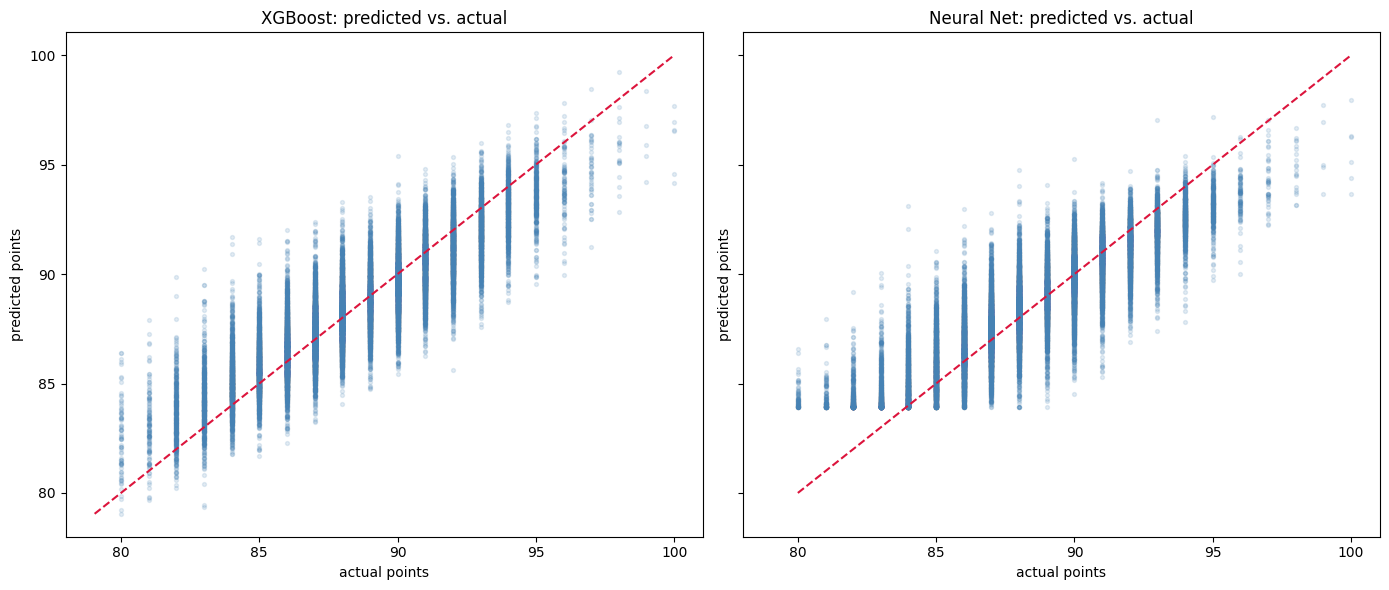

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

for ax, label, pred in zip(axes, ("XGBoost", "Neural Net"), (xgb_pred, nn_pred)):
    ax.scatter(y_test, pred, alpha=0.15, s=8, color="steelblue")
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, color="crimson", lw=1.5, linestyle="--")
    ax.set_xlabel("actual points")
    ax.set_ylabel("predicted points")
    ax.set_title(f"{label}: predicted vs. actual")

plt.tight_layout()
plt.show()

if WANDB_ENABLED:
    wandb.log({"predicted_vs_actual": wandb.Image(fig)})

## Step 6 — SHAP comparison (fresh, against the current best checkpoints)

`TreeExplainer` for XGBoost, `GradientExplainer` for the NN — same explainers and the same `_GradientExplainerOutput` output-dim wrapper notebook 04's SHAP cell already established and verified (`WineScoreNet.forward` returns a flat `(batch,)` tensor; `GradientExplainer` needs `(batch, n_outputs)`).

XGBoost — top 15 features by mean |SHAP|:
      feature  mean_abs_shap
     gorgeous       0.863864
        lacks       0.840598
    dominates       0.704396
         lean       0.617686
      generic       0.611184
      perfect       0.548866
       grainy       0.541427
       medium       0.519092
  light color       0.507874
        focus       0.460393
  meyer lemon       0.438507
barrel sample       0.406967
         pipe       0.403194
        grape       0.392417
 blackberries       0.383253


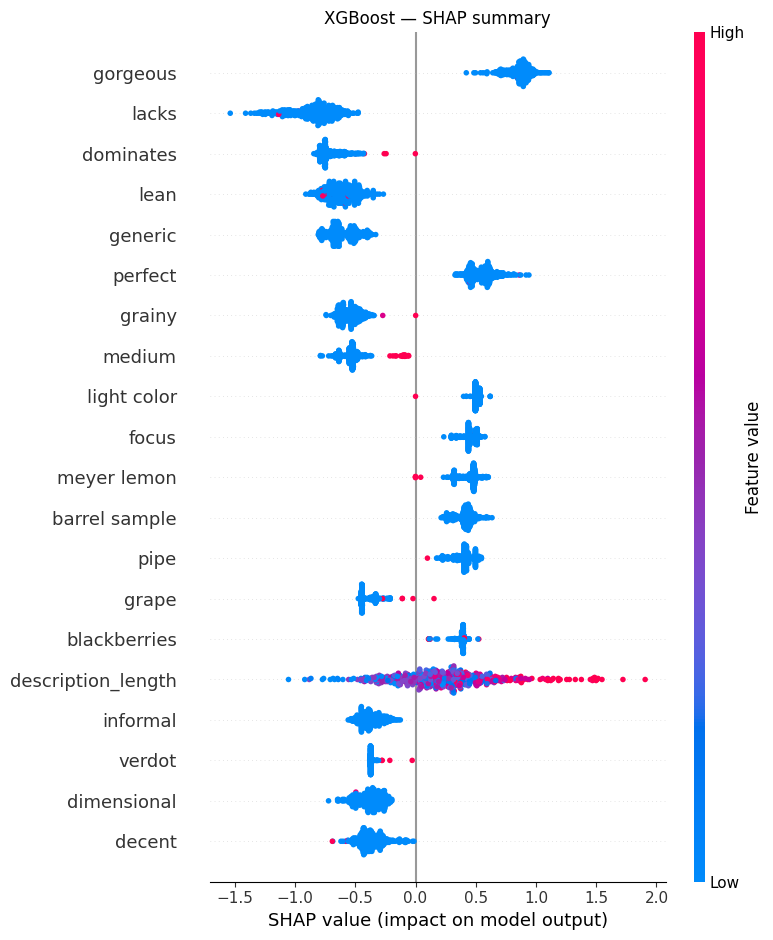


Neural Net — top 15 features by mean |SHAP|:
            feature  mean_abs_shap
  winery_avg_points       0.651610
 description_length       0.393733
   price_vs_variety       0.233086
        winery_freq       0.126744
          log_price       0.125693
           wine_age       0.119632
 variety_avg_points       0.112509
 region1_avg_points       0.092585
              is_us       0.078992
 country_avg_points       0.073057
           has_rich       0.072041
province_avg_points       0.068141
  taster_avg_points       0.067192
  taster_strictness       0.067045
       region1_freq       0.062655


C:\Users\leona\AppData\Local\Temp\ipykernel_30148\2455973237.py:68: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


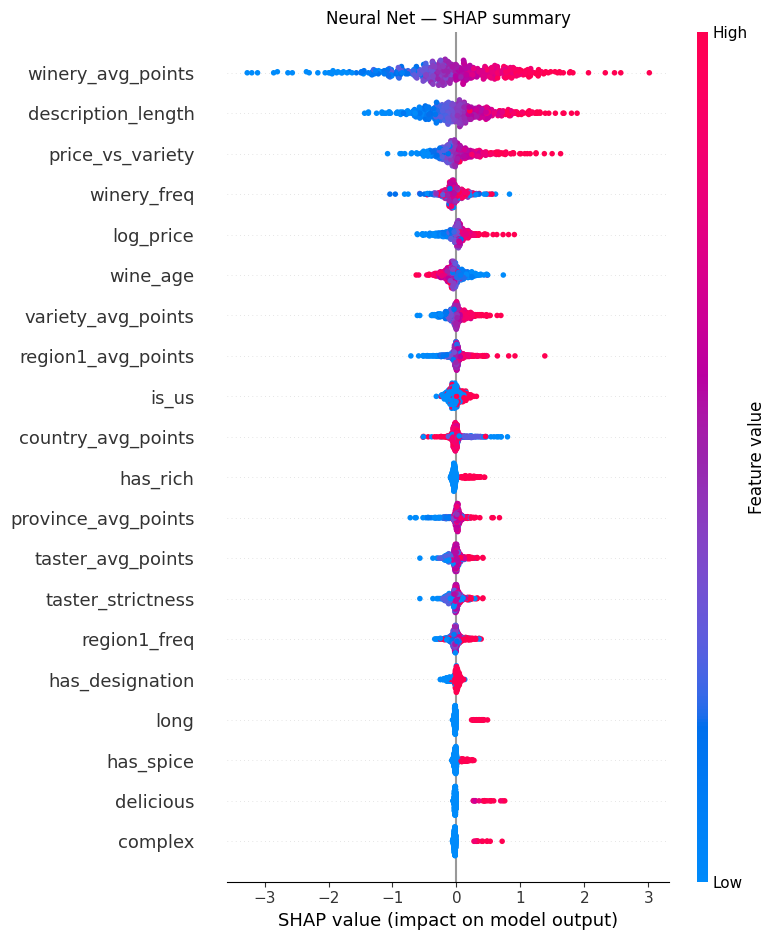

In [7]:
SHAP_SAMPLE_SIZE = 500
SHAP_BACKGROUND_SIZE = 100

rng = np.random.default_rng(RANDOM_STATE)
n_test = X_test_xgb.shape[0]
sample_idx = rng.choice(n_test, size=min(SHAP_SAMPLE_SIZE, n_test), replace=False)

X_xgb_sample = X_test_xgb[sample_idx]
if sparse.issparse(X_xgb_sample):
    X_xgb_sample = X_xgb_sample.toarray()

xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_xgb_sample)
xgb_mean_abs_shap = np.abs(xgb_shap_values).mean(axis=0)
xgb_top_idx = np.argsort(xgb_mean_abs_shap)[::-1][:30]
xgb_shap_table = pd.DataFrame(
    {
        "feature": [feature_names[i] for i in xgb_top_idx],
        "mean_abs_shap": xgb_mean_abs_shap[xgb_top_idx],
    }
)
print("XGBoost — top 15 features by mean |SHAP|:")
print(xgb_shap_table.head(15).to_string(index=False))

shap.summary_plot(
    xgb_shap_values, X_xgb_sample, feature_names=feature_names, max_display=20, show=False
)
xgb_shap_fig = plt.gcf()
plt.title("XGBoost — SHAP summary")
plt.tight_layout()
plt.show()


class _GradientExplainerOutput(nn.Module):
    """Adds back the output dim shap.GradientExplainer needs -- same wrapper
    as notebook 04's SHAP cell (WineScoreNet.forward returns a flat (batch,)
    tensor; GradientExplainer indexes outputs as outputs[:, i])."""

    def __init__(self, model: nn.Module) -> None:
        super().__init__()
        self.model = model

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x).unsqueeze(-1)


background_idx = rng.choice(n_test, size=SHAP_BACKGROUND_SIZE, replace=False)
background = torch.from_numpy(X_test_nn[background_idx])
X_nn_sample = torch.from_numpy(X_test_nn[sample_idx])

nn_explainer = shap.GradientExplainer(_GradientExplainerOutput(nn_net), background)
nn_shap_values = nn_explainer.shap_values(X_nn_sample)
if isinstance(nn_shap_values, list):
    nn_shap_values = nn_shap_values[0]
nn_shap_values = np.asarray(nn_shap_values).reshape(len(sample_idx), -1)

nn_mean_abs_shap = np.abs(nn_shap_values).mean(axis=0)
nn_top_idx = np.argsort(nn_mean_abs_shap)[::-1][:30]
nn_shap_table = pd.DataFrame(
    {
        "feature": [feature_names[i] for i in nn_top_idx],
        "mean_abs_shap": nn_mean_abs_shap[nn_top_idx],
    }
)
print("\nNeural Net — top 15 features by mean |SHAP|:")
print(nn_shap_table.head(15).to_string(index=False))

shap.summary_plot(
    nn_shap_values, X_nn_sample.numpy(), feature_names=feature_names, max_display=20, show=False
)
nn_shap_fig = plt.gcf()
plt.title("Neural Net — SHAP summary")
plt.tight_layout()
plt.show()

if WANDB_ENABLED:
    wandb.log(
        {
            "shap_xgboost": wandb.Image(xgb_shap_fig),
            "shap_xgboost_table": wandb.Table(dataframe=xgb_shap_table),
            "shap_nn": wandb.Image(nn_shap_fig),
            "shap_nn_table": wandb.Table(dataframe=nn_shap_table),
        }
    )

## Step 7 — Comparison charts

Four charts supporting the critical-analysis questions below, computed entirely from data already available (Steps 1-4) — no new predictions or model calls.

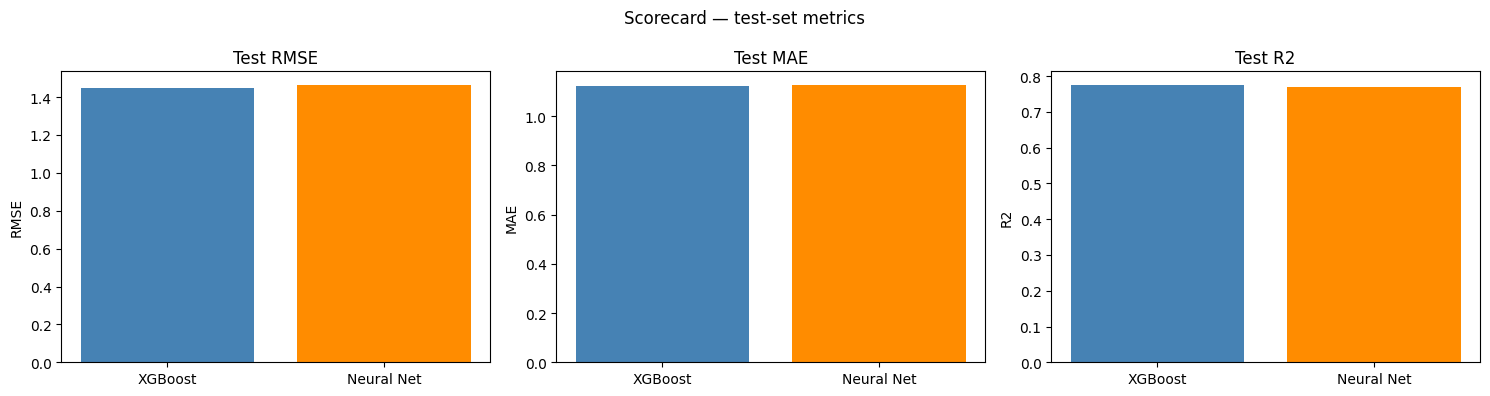

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metric_specs = [("test_rmse", "RMSE"), ("test_mae", "MAE"), ("test_r2", "R2")]

for ax, (col, label) in zip(axes, metric_specs):
    ax.bar(comparison_df["model"], comparison_df[col], color=["steelblue", "darkorange"])
    ax.set_title(f"Test {label}")
    ax.set_ylabel(label)

plt.suptitle("Scorecard — test-set metrics")
plt.tight_layout()
plt.show()

if WANDB_ENABLED:
    wandb.log({"scorecard": wandb.Image(fig)})

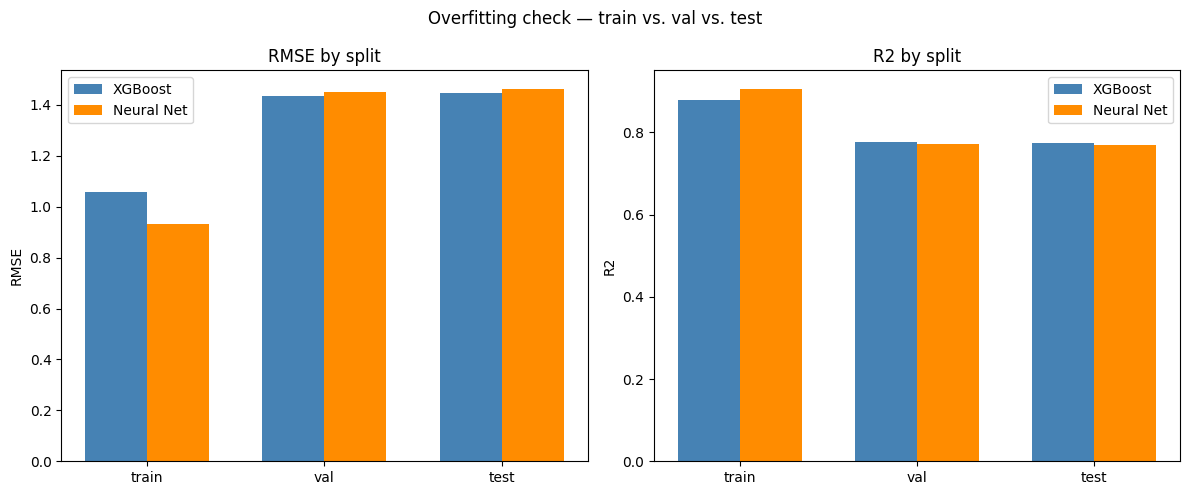

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
splits = ["train", "val", "test"]
width = 0.35
x = np.arange(len(splits))

for ax, (metric, label) in zip(axes, [("rmse", "RMSE"), ("r2", "R2")]):
    xgb_vals = [
        comparison_df.loc[comparison_df["model"] == "XGBoost", f"{s}_{metric}"].iloc[0]
        for s in splits
    ]
    nn_vals = [
        comparison_df.loc[comparison_df["model"] == "Neural Net", f"{s}_{metric}"].iloc[0]
        for s in splits
    ]
    ax.bar(x - width / 2, xgb_vals, width, label="XGBoost", color="steelblue")
    ax.bar(x + width / 2, nn_vals, width, label="Neural Net", color="darkorange")
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.set_ylabel(label)
    ax.set_title(f"{label} by split")
    ax.legend()

plt.suptitle("Overfitting check — train vs. val vs. test")
plt.tight_layout()
plt.show()

if WANDB_ENABLED:
    wandb.log({"overfitting_bars": wandb.Image(fig)})

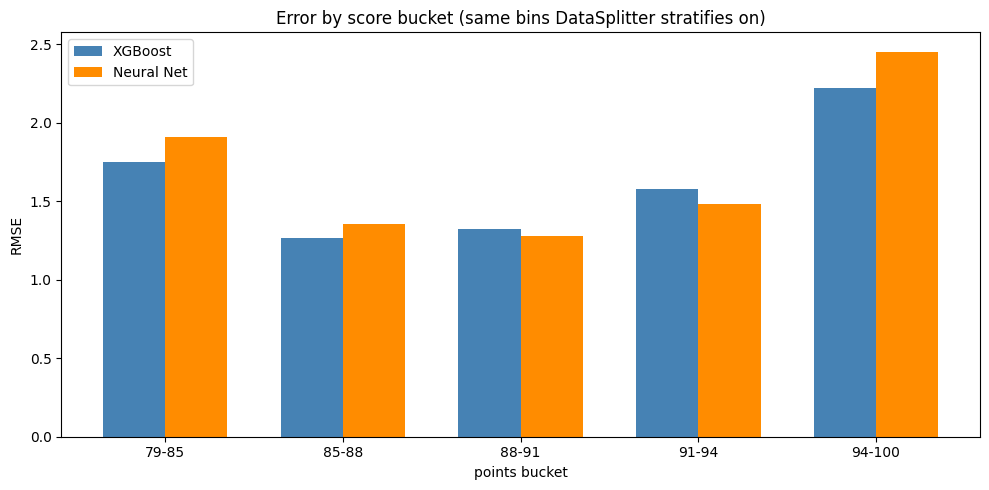

In [10]:
bucket_labels = [f"{POINTS_BINS[i]}-{POINTS_BINS[i + 1]}" for i in range(len(POINTS_BINS) - 1)]
buckets = pd.cut(y_test, bins=POINTS_BINS, labels=bucket_labels, include_lowest=True)

bucket_df = pd.DataFrame(
    {
        "bucket": buckets,
        "xgb_abs_error": np.abs(y_test - xgb_pred),
        "nn_abs_error": np.abs(y_test - nn_pred),
    }
)
bucket_rmse = bucket_df.groupby("bucket", observed=True).agg(
    xgboost=("xgb_abs_error", lambda e: np.sqrt(np.mean(e**2))),
    neural_net=("nn_abs_error", lambda e: np.sqrt(np.mean(e**2))),
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(bucket_rmse))
width = 0.35
ax.bar(x - width / 2, bucket_rmse["xgboost"], width, label="XGBoost", color="steelblue")
ax.bar(x + width / 2, bucket_rmse["neural_net"], width, label="Neural Net", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(bucket_rmse.index)
ax.set_xlabel("points bucket")
ax.set_ylabel("RMSE")
ax.set_title("Error by score bucket (same bins DataSplitter stratifies on)")
ax.legend()
plt.tight_layout()
plt.show()

if WANDB_ENABLED:
    wandb.log({"error_by_points_bucket": wandb.Image(fig)})

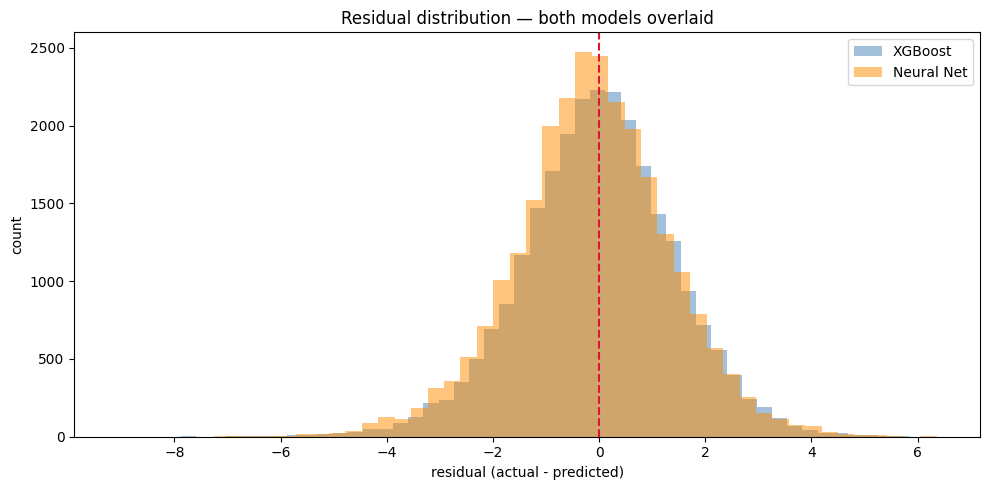

nn_run_id,nn_training_wide_v1-...
xgboost_run_id,xgboost_tuning_text_...


In [11]:
xgb_residuals = y_test - xgb_pred
nn_residuals = y_test - nn_pred

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(xgb_residuals, bins=50, alpha=0.5, color="steelblue", label="XGBoost")
ax.hist(nn_residuals, bins=50, alpha=0.5, color="darkorange", label="Neural Net")
ax.axvline(0, color="crimson", lw=1.5, linestyle="--")
ax.set_xlabel("residual (actual - predicted)")
ax.set_ylabel("count")
ax.set_title("Residual distribution — both models overlaid")
ax.legend()
plt.tight_layout()
plt.show()

if WANDB_ENABLED:
    wandb.log({"residual_overlay": wandb.Image(fig)})
    wandb.finish()

## Step 8 — Critical analysis

**Which model performed best, and why?**

XGBoost, marginally — see the scorecard and error-by-score-bucket charts above (Step 7). Test RMSE 1.445 vs. the NN's 1.463 (test R² 0.775 vs. 0.769), about a 1.2% relative RMSE difference. XGBoost's edge traces directly to how it uses the TF-IDF block: its SHAP ranking (Step 6 above) is dominated by individual text tokens, meaning gradient-boosted trees exploit thousands of sparse word-presence signals very directly. The NN reaches nearly the same accuracy through a different, more diffuse mechanism — leaning primarily on the 44 engineered tabular aggregates, with the TF-IDF signal spread thin across many individually-weak columns (confirmed via the tabular-only ablation in notebook 04b: removing TF-IDF entirely cost the NN ~0.15 R², so the text block matters collectively even though no single term ranks highly in its SHAP output).

**Did the neural network beat classical ML? Was that expected?**

No — XGBoost stayed narrowly ahead through every round of NN improvements this project tried (dense-data preloading, a wider Optuna search, activation choice, gradient clipping, an LR scheduler). This is the expected outcome for this dataset: ~130k rows of mixed tabular + sparse bag-of-words features is squarely gradient-boosted-tree territory — GBMs are well known to be hard to beat on structured/tabular data at this scale, especially against a from-scratch MLP with no sequence-aware text modeling (an RNN/Transformer trained from scratch, or a pretrained sentence-embedding block, were both considered as ways to give the NN a genuine structural edge on the text — see "what to improve" below, neither was attempted). The more interesting finding wasn't that the NN lost, but how close it got once its own training dynamics — not the feature set — turned out to be the limiting factor: early NN runs were actually *underfitting* (train R² well below XGBoost's), and most of the gain came from letting it fit harder, not from new data or features.

**Overfitting: signs, detection, mitigation**

Detected directly from the Step 4 table and the overfitting-bars chart in Step 7 above — each model's own train-vs-test gap:

| model | train R² | test R² | gap |
|---|---|---|---|
| XGBoost | 0.878 | 0.775 | 0.103 |
| Neural Net | 0.906 | 0.769 | 0.137 |

Both models show a real but moderate gap — neither is wildly overfit, though the NN's is now slightly larger than XGBoost's, a direct consequence of the tuning work: earlier NN runs (10-20 trials) actually underfit, and closing that gap through a wider search and stronger-regularization hyperparameters (dropout up to 0.44, weight_decay up to 0.0025) pushed train R² past XGBoost's own, at some cost to the train-test gap. Mitigation already applied on both sides: XGBoost's Optuna search tunes `reg_alpha`/`reg_lambda`/`subsample`/`colsample_bytree`/`gamma` plus early stopping against a validation set; the NN uses dropout, weight decay, BatchNorm, early stopping, and (added this session) gradient clipping and an LR scheduler.

**Most relevant features**

See the SHAP tables/plots in Step 6 above for this run's actual ranking. Consistent with every SHAP run in this project so far: XGBoost's top-ranked features are expected to be dominated by individual TF-IDF terms, while the NN's are expected to be dominated by the engineered tabular aggregates (`winery_avg_points`, `description_length`, `price_vs_variety`, and similar groupby-based features) — the two models lean on almost entirely different parts of the same feature space to reach similar accuracy.

**What would you improve with more time or data?**

- Replace the TF-IDF block with a frozen pretrained sentence-embedding (e.g. `sentence-transformers`) for the NN — same "concatenate as another dense block" architecture, no RNN/Transformer training required, likely a stronger and more efficient text representation than TF-IDF.
- Exclude BatchNorm/bias parameters from weight decay (a well-known but not-yet-applied best practice — AdamW currently regularizes every parameter uniformly).
- Widen the Optuna search further now that pruning and dense-preloading cut wall-clock substantially (more trials, per-layer dropout, independently-searched depth/width instead of fixed architecture strings).
- More data, particularly for underrepresented varieties/regions/tasters — SHAP consistently ranks `variety_avg_points`/`region1_avg_points`/`taster_strictness`-style aggregate features highly, and those are exactly the features most sensitive to small-sample noise for rare categories.
- A cheap ensemble (blend/average XGBoost + NN predictions) — the two models reach similar accuracy through different mechanisms (individual words vs. tabular aggregates), so their errors may be meaningfully decorrelated.